# Module 05: Scikit-Learn for Machine Learning
## Notebook 02: Supervised Regression Models and Regularization

Regression models predict continuous quantities (house prices, customer lifetime spend, temperature). In this notebook, we explore the bias-variance trade-off, regularized regression ($L_1$ and $L_2$), and residual diagnostics.

---

### Learning Objectives
By the end of this notebook, you will be able to:
1. Fit Ordinary Least Squares (**`LinearRegression`**) models.
2. Apply $L_2$ shrinkage via **Ridge Regression** to mitigate multicollinearity.
3. Perform automated feature selection with $L_1$ sparse penalties using **Lasso Regression**.
4. Evaluate regression performance using **MSE**, **RMSE**, **MAE**, and **$R^2$ Score**.
5. Construct and analyze **Residual Diagnostics Plots** to verify model assumptions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Loaded Scikit-Learn Regression Modules!")

Loaded Scikit-Learn Regression Modules!


### 1. Generating a Synthetic Regression Dataset

We simulate a dataset where:
- 10 total features.
- Only 3 features are genuinely predictive (informative).
- 7 features are pure uninformative noise.

In [2]:
X, y, true_coef = make_regression(
    n_samples=250, 
    n_features=10, 
    n_informative=3, 
    noise=12.0, 
    coef=True, 
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"True non-zero feature coefficients:\n", np.round(true_coef, 2))

True non-zero feature coefficients:
 [11.04 68.51  0.    0.   81.41  0.    0.    0.    0.    0.  ]


---
### 2. Regularization in Action: OLS vs. Ridge ($L_2$) vs. Lasso ($L_1$)

- **LinearRegression (OLS)**: Fits weights without penalty. Overfits when features are correlated or noisy.
- **Ridge ($L_2$)**: Minimizes $\text{MSE} + \alpha \sum w_i^2$. Shrinks weights close to zero, reducing variance.
- **Lasso ($L_1$)**: Minimizes $\text{MSE} + \alpha \sum |w_i|$. Forces coefficients of uninformative features to **exactly zero**, performing automated feature selection!

In [3]:
# 1. Fit Ordinary Least Squares
ols = LinearRegression().fit(X_train, y_train)

# 2. Fit Ridge (L2 penalty)
ridge = Ridge(alpha=10.0).fit(X_train, y_train)

# 3. Fit Lasso (L1 penalty)
lasso = Lasso(alpha=2.5).fit(X_train, y_train)

# Compare learned coefficients
coef_comparison = pd.DataFrame({
    'True_Coef': true_coef,
    'OLS_Coef': ols.coef_,
    'Ridge_Coef': ridge.coef_,
    'Lasso_Coef': lasso.coef_
}).round(2)

print("Learned Feature Coefficients Comparison:\n", coef_comparison)

Learned Feature Coefficients Comparison:
    True_Coef  OLS_Coef  Ridge_Coef  Lasso_Coef
0      11.04     11.03       11.14        8.82
1      68.51     68.13       64.92       65.66
2       0.00     -0.29       -0.04        0.00
3       0.00     -2.02       -1.87       -0.00
4      81.41     80.76       75.76       78.38
5       0.00      1.07        1.05        0.00
6       0.00      0.47       -0.67       -0.00
7       0.00     -0.28        0.08       -0.00
8       0.00     -0.23       -0.46       -0.00
9       0.00     -0.58       -1.05       -0.00


---
### 3. Evaluating Regression Performance Metrics

Key regression metrics:
- **MAE**: Average absolute error (interpretable, robust to outliers).
- **MSE / RMSE**: Penalizes large prediction errors quadratically.
- **$R^2$ Score**: Proportion of target variance explained by the model ($1.0$ is perfect, $0.0$ equals predicting the mean).

In [4]:
models = {'OLS': ols, 'Ridge': ridge, 'Lasso': lasso}
results = []

for name, model in models.items():
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append({'Model': name, 'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'R2_Score': round(r2, 4)})

print("Model Evaluation on Unseen Test Data:\n", pd.DataFrame(results))

Model Evaluation on Unseen Test Data:
    Model   RMSE    MAE  R2_Score
0    OLS  11.83  10.06    0.9868
1  Ridge  13.08  10.97    0.9838
2  Lasso  11.30   9.55    0.9879


---
### 4. Residual Diagnostics Plotting

A valid linear regression model assumes errors (residuals $e_i = y_i - \hat{y}_i$) are normally distributed and homoscedastic (constant variance across predicted values).

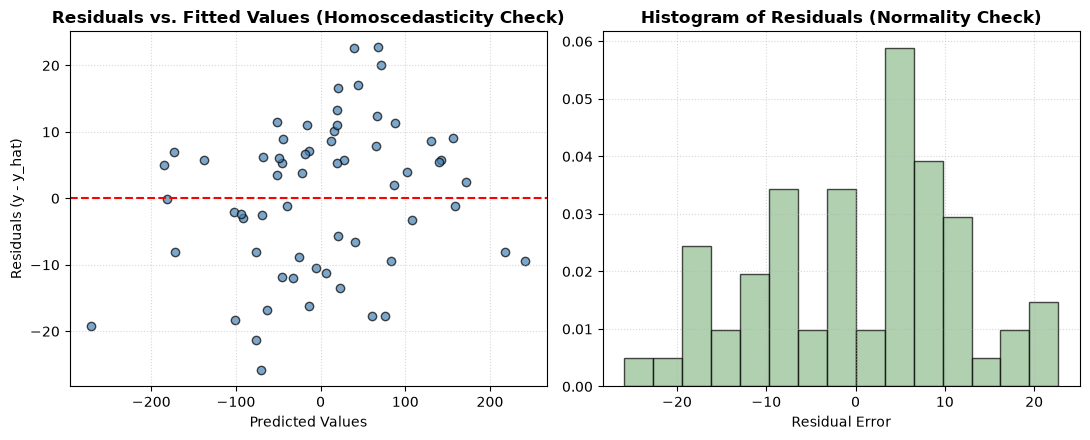

In [5]:
lasso_preds = lasso.predict(X_test)
residuals = y_test - lasso_preds

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# 1. Residuals vs Predicted Values
ax1.scatter(lasso_preds, residuals, color='steelblue', edgecolor='k', alpha=0.7)
ax1.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax1.set_title("Residuals vs. Fitted Values (Homoscedasticity Check)", fontweight='bold')
ax1.set_xlabel("Predicted Values")
ax1.set_ylabel("Residuals (y - y_hat)")
ax1.grid(True, linestyle=':', alpha=0.5)

# 2. Residual Distribution (Normality Check)
ax1_hist = ax2.hist(residuals, bins=15, color='darkseagreen', edgecolor='k', alpha=0.7, density=True)
ax2.set_title("Histogram of Residuals (Normality Check)", fontweight='bold')
ax2.set_xlabel("Residual Error")
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### Summary & Next Steps
In this notebook, you mastered:
- Ordinary Least Squares vs regularized regression (Ridge, Lasso, ElasticNet).
- How Lasso performs sparse feature selection.
- RMSE, MAE, and $R^2$ regression metrics.
- Residual diagnostics plotting to verify linear assumptions.

**Next Notebook:** `03_supervised_classification_models.ipynb` — Logistic Regression, Decision Trees, Random Forests, ROC curves, and imbalanced class handling.